# Paper exec-throttle — V-shapes (desk memo)

MinV / EGARCH **Promote** monitors → simulated desk throttle vs always-on baseline.

| | |
|--|--|
| Primary trigger | UTC-day MinV < EGARCH 5% · window `[τ★, τ★+h_n]` |
| Secondary | Calendar Ridge score (Monitor) — paper-only deepen |
| Primary gate | **Kill** as `—` |
| Alpha | **Hold** always (`y_tick_20` stays Hold) |
| Fills | Synthetic maker × tape print + friction — no fantasy |

**SoT:** [`NOTES.md`](NOTES.md) · [`EXP_REPORT.md`](EXP_REPORT.md) · [`CANDIDATES.md`](CANDIDATES.md) · artifacts [`../../out/paper_throttle/`](../../out/paper_throttle/) · Desk [`../../DESK_MEMO.md`](../../DESK_MEMO.md) · Trade ideas [`../../notebooks/trade_ideas.ipynb`](../../notebooks/trade_ideas.ipynb).

Script: [`../../scripts/exp_paper_throttle.py`](../../scripts/exp_paper_throttle.py). ClickHouse MCP banned.


## 1. Theory — why throttle, not fade

Flora–Renò MinV significance flags **reverting-drift / fragility** days. Desk job is risk overlay:

- Widen quotes + cut size + pause aggressive takes for `1×h_n` after trough detection
- Not a mean-reversion fade (that candidate remains Hold — post-trough CI includes 0)
- Calendar Ridge Monitor may **reinforce** throttle weight; never standalone size


## 2. Method — honesty bar

| Item | Choice |
|------|--------|
| Trigger | Promote EGARCH MinV `sig_5` at τ★ |
| Causality | Throttle starts at τ★ (trough observed) |
| Baseline | Always-on maker on same tape |
| Fills | Participation × size_mult; fill @ print ± (base+widen) bps |
| OOS | Chronological day split ~60/40 |
| Falsifier | Placebo random windows; early∧late; risk CI |
| Promote bar | Risk improves OOS (DD / adverse mo) even if PnL flat; **Hold as alpha** |


## 3. Load artifacts


In [1]:
from pathlib import Path
import json
from IPython.display import Image, display, Markdown

BOOK = Path('../..').resolve()
OUT = BOOK / 'out' / 'paper_throttle'
FIG = OUT / 'figs'
summary = json.loads((OUT / 'summary.json').read_text())
gates = json.loads((OUT / 'gates.json').read_text())
deltas = json.loads((OUT / 'delta_rows.json').read_text())
print('ok_days', summary['sample']['n_ok_days'], 'breach', summary['sample']['n_breach_dayvenue'])
print('train', summary['sample']['train_days'])
print('test ', summary['sample']['test_days'])
print('knobs', summary['knobs'])


ok_days 99 breach 16
train ['2026-09-04', '2026-09-05', '2026-09-06', '2026-09-07', '2026-09-08', '2026-09-09', '2026-09-10', '2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18']
test  ['2026-09-19', '2026-09-20', '2026-09-21', '2026-09-22', '2026-09-25', '2026-09-26', '2026-09-27', '2026-09-30']
knobs {'throttle_size_mult': 0.35, 'throttle_widen_bps': 5.0, 'throttle_pov': 0.2, 'cal_boost_size_mult': 0.22, 'cal_boost_widen_bps': 8.0, 'base_friction_bps': 2.0, 'base_size': 0.25, 'hn_set_min': [1, 5, 30]}


## 4. OOS risk / PnL board


In [2]:
import pandas as pd
rows = []
for label, key in [
    ('OOS all', 'agg_oos'),
    ('OOS breach', 'agg_oos_breach'),
    ('OOS calm', 'agg_oos_calm'),
    ('OOS early', 'agg_oos_early'),
    ('OOS late', 'agg_oos_late'),
    ('train', 'agg_train'),
]:
    blk = summary.get(key) or {}
    def m(k):
        b = blk.get(k) or {}
        return b.get('mean'), (b.get('lo'), b.get('hi')), b.get('n')
    dd, ddci, n = m('d_max_dd_throttle')
    adv, advci, _ = m('d_adverse_mo_throttle')
    pnl, pnlci, _ = m('d_pnl_throttle')
    rows.append(dict(slice=label, n=blk.get('n'), d_max_dd=dd, dd_ci=ddci, d_adverse_mo30=adv, adv_ci=advci, d_pnl=pnl))
display(pd.DataFrame(rows))
print('placebo OOS', (summary.get('agg_oos') or {}).get('d_max_dd_placebo'), (summary.get('agg_oos') or {}).get('d_adverse_mo_placebo'))


,slice,n,d_max_dd,dd_ci,d_adverse_mo30,adv_ci,d_pnl
0,OOS all,36,2.380758,"(-8.270923266180034, 7.250310978126962)",0.001412,"(0.0, 0.0024180441757507562)",2.380948
1,OOS breach,5,17.141459,"(-75.80812122106872, 70.22538386792658)",0.010167,"(0.004401993392844528, 0.014693676653755539)",17.142825
2,OOS calm,31,0.000000,"(0.0, 0.0)",0.000000,"(0.0, 0.0)",0.000000
3,OOS early,12,0.561498,"(-24.812769798540103, 12.64988664255361)",0.003720,"(0.0, 0.006122365272398141)",0.561498
4,OOS late,24,3.290388,"(0.0, 9.871164310538461)",0.000258,"(0.0, 0.0007744285237917814)",3.290673
5,train,63,43.738476,"(6.904602370445865, 102.77187747209487)",0.003558,"(0.0010175640792400114, 0.006974822087567578)",43.744394


placebo OOS {'mean': -6.19936783401834, 'lo': -14.828390414099509, 'hi': 0.7763992149379343, 'n': 36} {'mean': 0.0008509222106939385, 'lo': 3.3799399754625486e-05, 'hi': 0.0017425729524507448, 'n': 36}


## 5. Figures


== breach_timeline.png exists


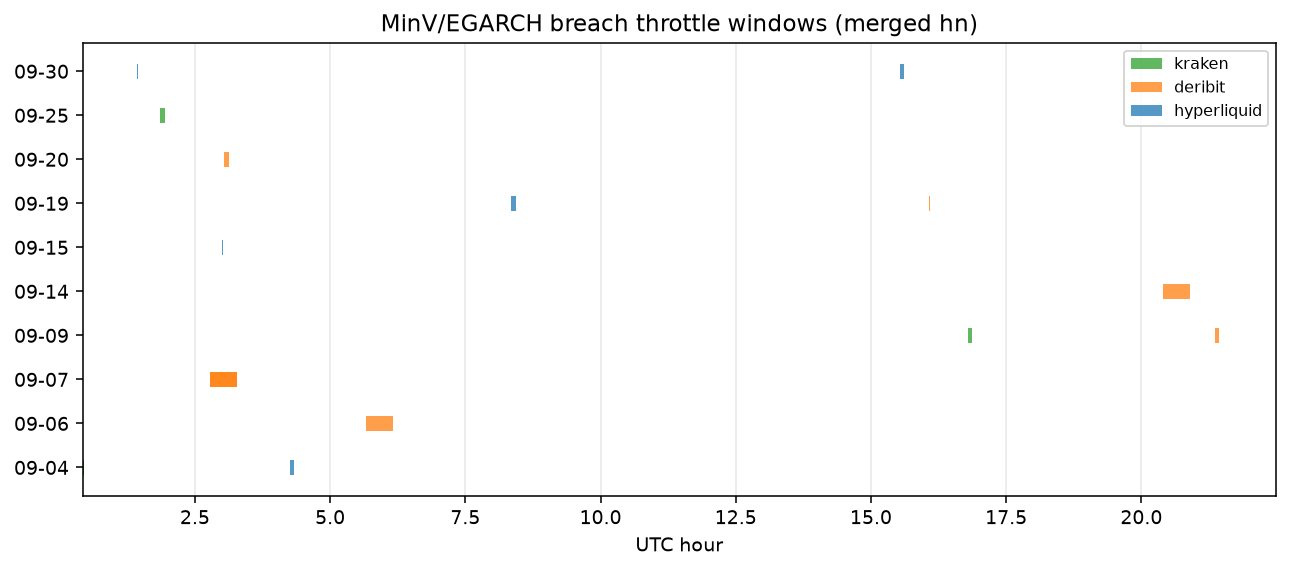

== oos_risk_deltas.png exists


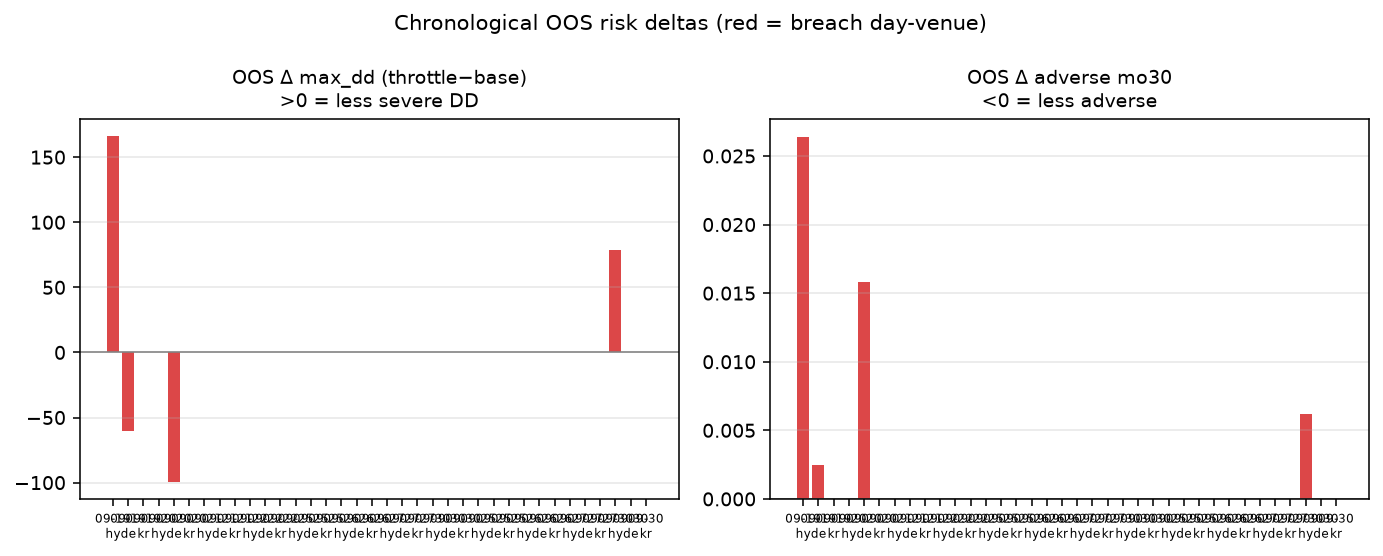

== cumulative_risk.png exists


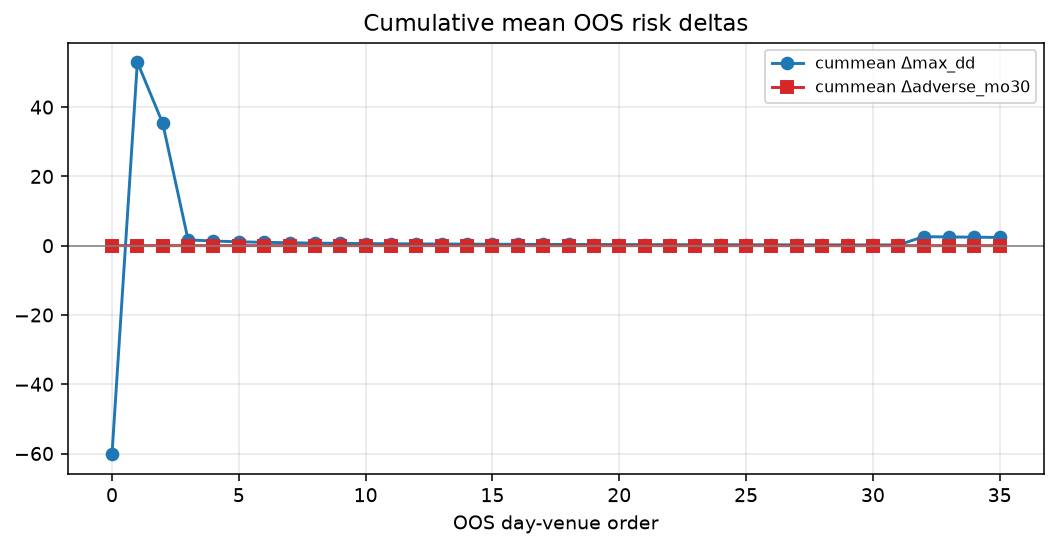

== throttle_state_path.png exists


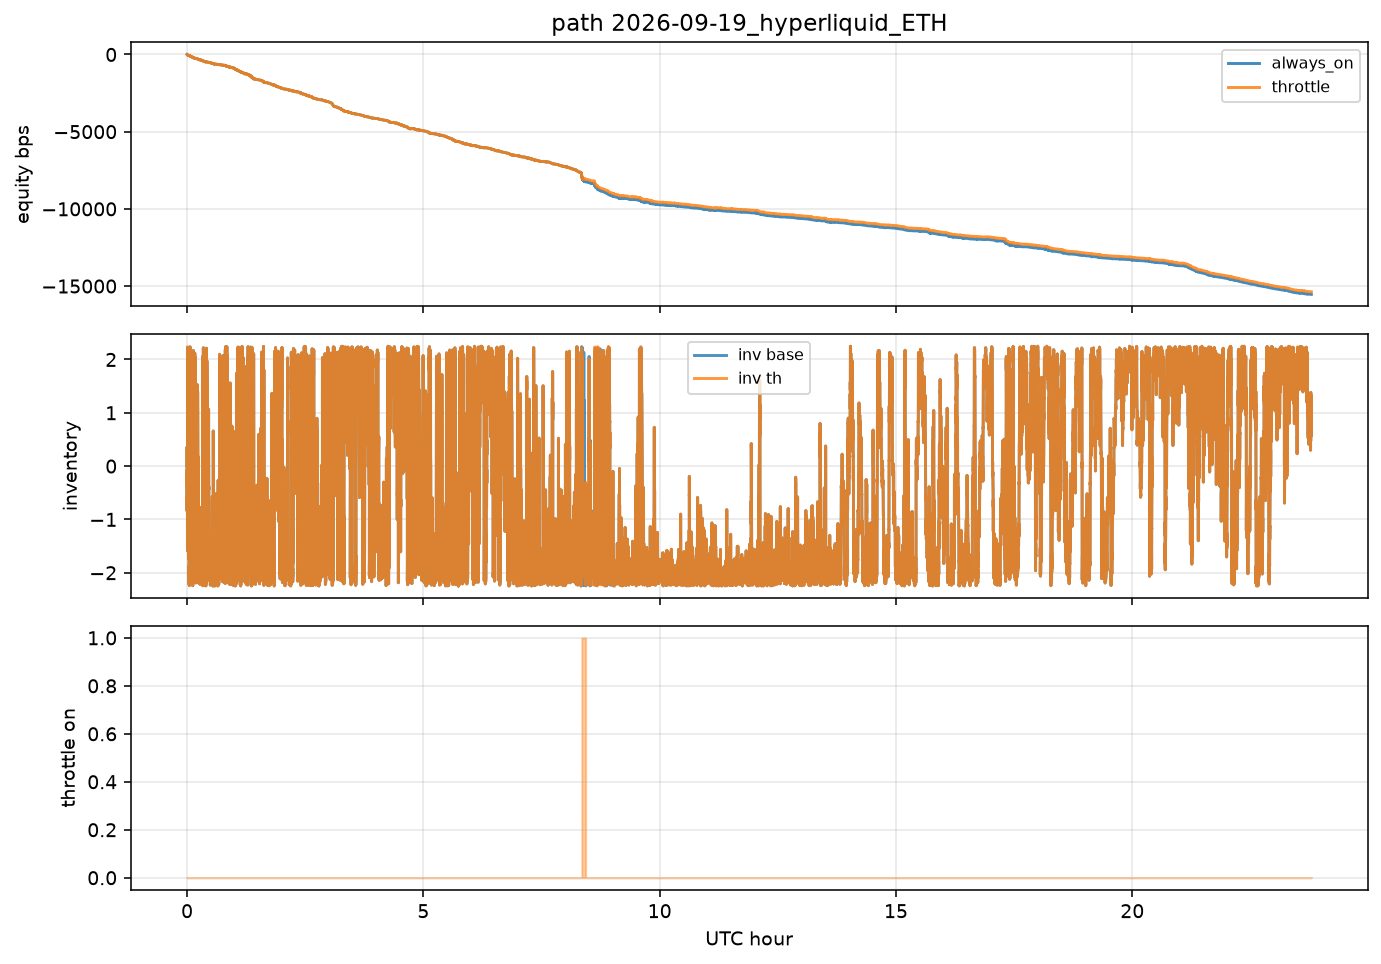

== policy_slice_bars.png exists


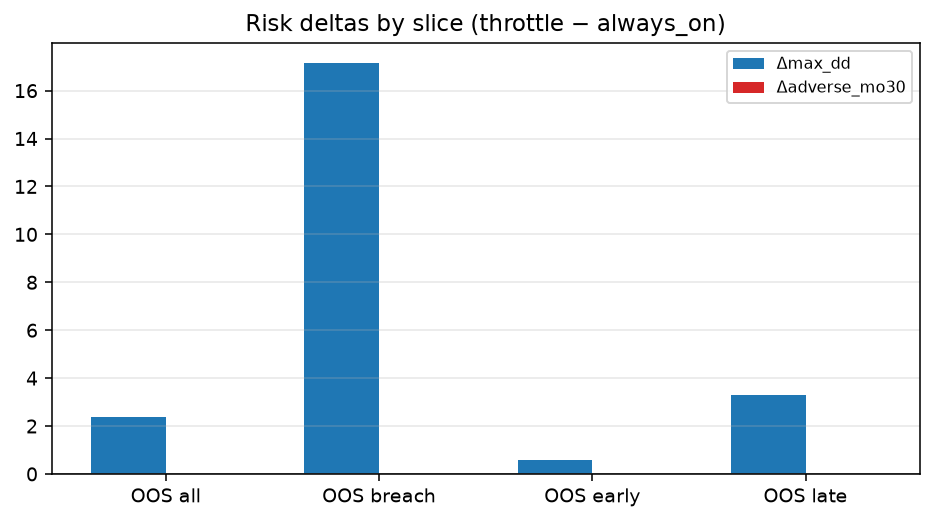

== pnl_vs_risk.png exists


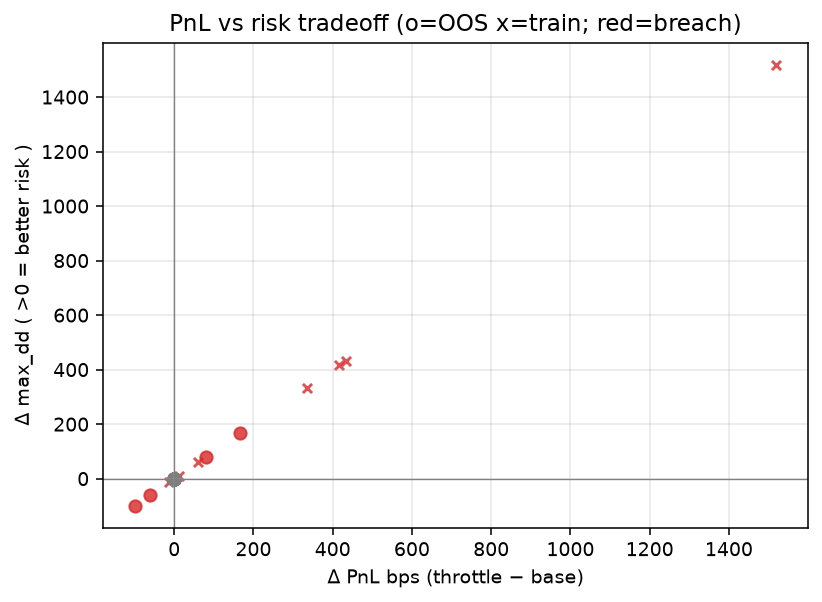

In [3]:
from IPython.display import Image, display
for name in [
    'breach_timeline.png',
    'oos_risk_deltas.png',
    'cumulative_risk.png',
    'throttle_state_path.png',
    'policy_slice_bars.png',
    'pnl_vs_risk.png',
]:
    p = FIG / name
    print('==', name, 'exists' if p.exists() else 'MISSING')
    if p.exists():
        display(Image(filename=str(p)))


## 6. Gate / candidates


In [4]:
import pandas as pd
display(pd.DataFrame(gates['candidates'])[['id','decision','lenses','evidence']])
print('--- trade ideas ---')
for ti in gates.get('trade_ideas_new') or []:
    print(ti['id'], ti['label'], ti['title'][:80])


,id,decision,lenses,evidence
0,exec.minv_breach_throttle,Kill,"exec, risk, mm",OOS Δmax_dd=17.14 boot={'mean': 17.14145928632...
1,exec.minv_throttle_cal_join,Hold,"exec, info, risk",cal-join OOS Δdd=24.75 Δadv=0.01044 vs plain Δ...
2,exec.minv_throttle_as_alpha,Hold,exec,PnL Δ OOS=2.381 — flat/negative expected; neve...
3,exec.placebo_throttle,Hold,exec,placebo Δdd=-6.199 Δadv=0.0008509 vs real Δdd=...


--- trade ideas ---
ti.paper_minv_exec_throttle Monitor MinV/EGARCH breach → widen / cut size / pause takes (paper harness)
ti.paper_cal_throttle_join Exec throttle (paper) Calendar Ridge score deepens breach throttle (paper-only weight)


## 7. Desk takeaway

- **Exec throttle / risk** Promote only if falsifiers hold (OOS risk help, placebo weaker, early∧late).
- **Hold as alpha** — flat PnL is acceptable; do not size on throttle PnL or `y_tick_20`.
- Calendar join is paper-only secondary weight on top of MinV breach.
- Live POV params still respect `info.v_path_continuous` Hold for continuity narrative.
